**Tutorial Code by Amirhossein Ahrari YouTube:** https://www.youtube.com/@amirhosseinahrarigee

**Tutorial Video: PySTAC Tutorial-11: Sentinel-2 Crop Area Calculation using Otsu Algorithm in Python**

This code is part of a tutorial series on python eo programming techniques
presented on the Amirhossein Ahrari YouTube channel. You are free to use and modify
this code for academic and non-academic purposes. Don't forget to subscribe to
the Amirhossein Ahrari channel and follow the videos to support the instructor.

In [1]:
!pip install -q pystac-client stackstac

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 598.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 3.4 MB/s eta 0:00:00


In [2]:
from pystac_client import Client

In [3]:
catalog = Client.open(
   'https://earth-search.aws.element84.com/v1'
)

In [4]:
for collection in catalog.get_collections():
  print(collection.id)

sentinel-2-pre-c1-l2a
cop-dem-glo-30
naip
cop-dem-glo-90
landsat-c2-l2
sentinel-2-l2a
sentinel-2-l1c
sentinel-2-c1-l2a
sentinel-1-grd


In [5]:
roi = [48.25666, 30.976395, 48.301277, 31.017615]

In [6]:
search = catalog.search(
    collections = ['sentinel-2-c1-l2a'],
    bbox = roi,
    datetime = '2023'
)

In [9]:
items = search.item_collection()

/usr/local/lib/python3.13/dist-packages/pystac/extensions/storage.py:724: UserWarning: Could not parse bucket/account from href. The following assets were not migrated: ['red', 'green', 'blue', 'visual', 'nir', 'swir22', 'rededge2', 'rededge3', 'rededge1', 'swir16', 'wvp', 'nir08', 'scl', 'aot', 'coastal', 'nir09', 'cloud', 'snow', 'preview', 'granule_metadata', 'tileinfo_metadata', 'product_metadata', 'thumbnail']
  warnings.warn(


In [10]:
len(items)

71

In [12]:
items[0].properties['proj:code']

'EPSG:32639'

In [13]:
items[0].assets.keys()

dict_keys(['red', 'green', 'blue', 'visual', 'nir', 'swir22', 'rededge2', 'rededge3', 'rededge1', 'swir16', 'wvp', 'nir08', 'scl', 'aot', 'coastal', 'nir09', 'cloud', 'snow', 'preview', 'granule_metadata', 'tileinfo_metadata', 'product_metadata', 'thumbnail'])

In [14]:
import stackstac

In [15]:
ds_stack = stackstac.stack(
    items,
    assets = ['red','nir','scl'],
    bounds_latlon = roi,
    resolution = 10,
    epsg = 32639
)

In [20]:
ds= (
    ds_stack.to_dataset('band')
    .drop_dims('band')
    .reset_coords(drop = True)
    .drop_attrs()
)

In [21]:
mask = ds.scl.isin([3,8,9,10]).astype(int)
ds_mask = ds[['nir','red']].where(mask == 0)

In [23]:
nir = ds['nir']
red = ds['red']
ndvi = (nir - red) / (nir + red)

In [24]:
ndvi_weekly = ndvi.resample(time = 'W').max('time')

In [25]:
from dask.diagnostics import ProgressBar

In [27]:
import warnings
warnings.filterwarnings('ignore', category = RuntimeWarning)
import logging
logging.getLogger().setLevel(logging.ERROR)

In [28]:
with ProgressBar():
  ndvi_weekly = ndvi_weekly.compute()

[########################################] | 100% Completed | 58.97 s


In [33]:
from scipy.signal import savgol_filter

In [36]:
ndvi_val = ndvi_weekly.values

In [41]:
ndvi_weekly

<xarray.DataArray (time: 52, y: 468, x: 438)> Size: 85MB
array([[[ 3.10650888e-02,  3.65398956e-02,  1.06707317e-02, ...,
          1.86206897e-01,  1.66110740e-01,  1.46682897e-01],
        [-9.24214418e-03,  3.20150659e-02,  3.73475610e-02, ...,
          1.94444444e-01,  1.65048544e-01,  1.73754557e-01],
        [-5.48054011e-02, -2.64299803e-02, -4.73933649e-03, ...,
          1.87150838e-01,  1.46408840e-01,  1.74025974e-01],
        ...,
        [ 1.19343610e-02,  1.12302195e-02,  6.98215671e-03, ...,
          2.06686930e-01,  2.04152249e-01,  2.22781867e-01],
        [ 6.92726373e-03,  9.15099136e-03, -1.54162384e-03, ...,
          1.91904048e-01,  1.91934279e-01,  2.15209125e-01],
        [ 9.42460317e-03,  1.01988781e-02, -1.03466115e-03, ...,
          1.97613721e-01,  2.20621683e-01,  2.32665639e-01]],

       [[ 9.92292871e-02,  9.70377937e-02,  9.56429330e-02, ...,
          1.46591970e-01,  1.37893594e-01,  1.47748890e-01],
        [ 7.23404255e-02,  8.35345244e-02,  1.08980827e-01, ...,
          1.07934943e-01,  1.34043746e-01,  1.43596378e-01],
        [ 7.52275994e-02,  9.26640927e-02,  1.69496093e-01, ...,
          8.99795501e-02,  1.25348189e-01,  1.17948718e-01],
...
        [ 6.95087521e-01,  7.34926052e-01,  4.35193945e-01, ...,
          4.22969188e-01,  4.47674419e-01,  4.72584856e-01],
        [ 7.45454545e-01,  7.52037253e-01,  3.90117647e-01, ...,
          4.52631579e-01,  3.77870564e-01,  4.85265226e-01],
        [ 7.07992093e-01,  7.15406162e-01,  4.07545412e-01, ...,
          3.78927911e-01,  4.90683230e-01,  3.97312860e-01]],

       [[ 2.99401198e-03,  1.12775330e-01,  8.27458256e-02, ...,
          1.69267707e-01,  2.06621704e-01,  2.82317979e-01],
        [ 3.50297422e-02,  1.35704875e-01,  4.83460560e-02, ...,
          1.77718833e-01,  1.96506550e-01,  2.07422134e-01],
        [ 1.18198874e-01,  1.11014367e-01,  6.26801153e-02, ...,
          1.85831063e-01,  2.18989280e-01,  2.21532091e-01],
        ...,
        [ 6.89391796e-01,  7.22415796e-01,  4.54545455e-01, ...,
          1.37135922e-01,  1.37783221e-01,  1.34638923e-01],
        [ 7.31513083e-01,  7.41664332e-01,  4.65433301e-01, ...,
          1.19383825e-01,  1.33501259e-01,  1.45212429e-01],
        [ 7.20283688e-01,  7.26159977e-01,  4.58834858e-01, ...,
          1.16498316e-01,  1.28818061e-01,  1.39642621e-01]]])
Coordinates:
  * time     (time) datetime64[ns] 416B 2023-01-08 2023-01-15 ... 2023-12-31
  * y        (y) float64 4kB 3.435e+06 3.435e+06 3.435e+06 ... 3.43e+06 3.43e+06
  * x        (x) float64 4kB 2.38e+05 2.38e+05 2.38e+05 ... 2.424e+05 2.424e+05

In [40]:
ndvi_val.shape

(52, 468, 438)

In [ ]:
help(savgol_filter)

In [54]:
ndvi_interp = ndvi_weekly.interpolate_na(dim = 'time', method = 'linear')
ndvi_interp = ndvi_interp.ffill('time').bfill('time')

In [55]:
ndvi_filter = savgol_filter(
    ndvi_interp.values,
    window_length = 10,
    polyorder = 2,
    axis = 0,
    mode = 'interp'
)

In [44]:
import xarray as xr

In [57]:
ndvi_sg = xr.DataArray(
    ndvi_filter,
    dims = ndvi_weekly.dims,
    coords = ndvi_weekly.coords
)

In [58]:
ndvi_monthly = ndvi_sg.resample(time = 'M').mean('time')

/usr/local/lib/python3.13/dist-packages/xarray/groupers.py:530: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


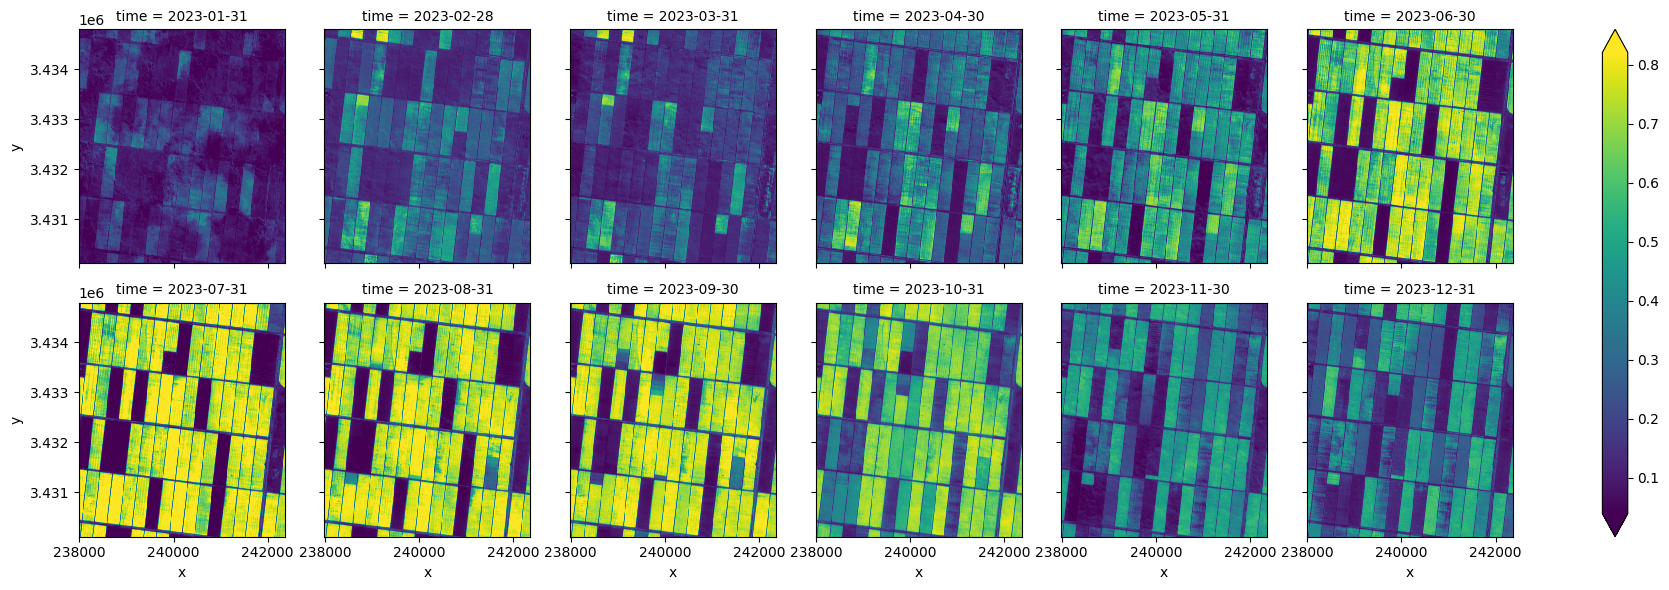

In [59]:
ndvi_monthly.plot(robust = True, col = 'time', col_wrap = 6)

In [60]:
from skimage.filters import threshold_otsu

In [63]:
thr = threshold_otsu(ndvi_monthly.values)

In [65]:
thr_list = []

for i in ndvi_monthly.time.values:
  img_sel = ndvi_monthly.sel(time = i).values
  thr_sel = threshold_otsu(img_sel)
  thr_list.append(thr_sel)


In [67]:
thr_xr = xr.DataArray(
    thr_list,
    dims = ['time'],
    coords = {'time': ndvi_monthly.time.values}
)

In [69]:
crop_layer = (ndvi_monthly >= thr_xr).astype(int)

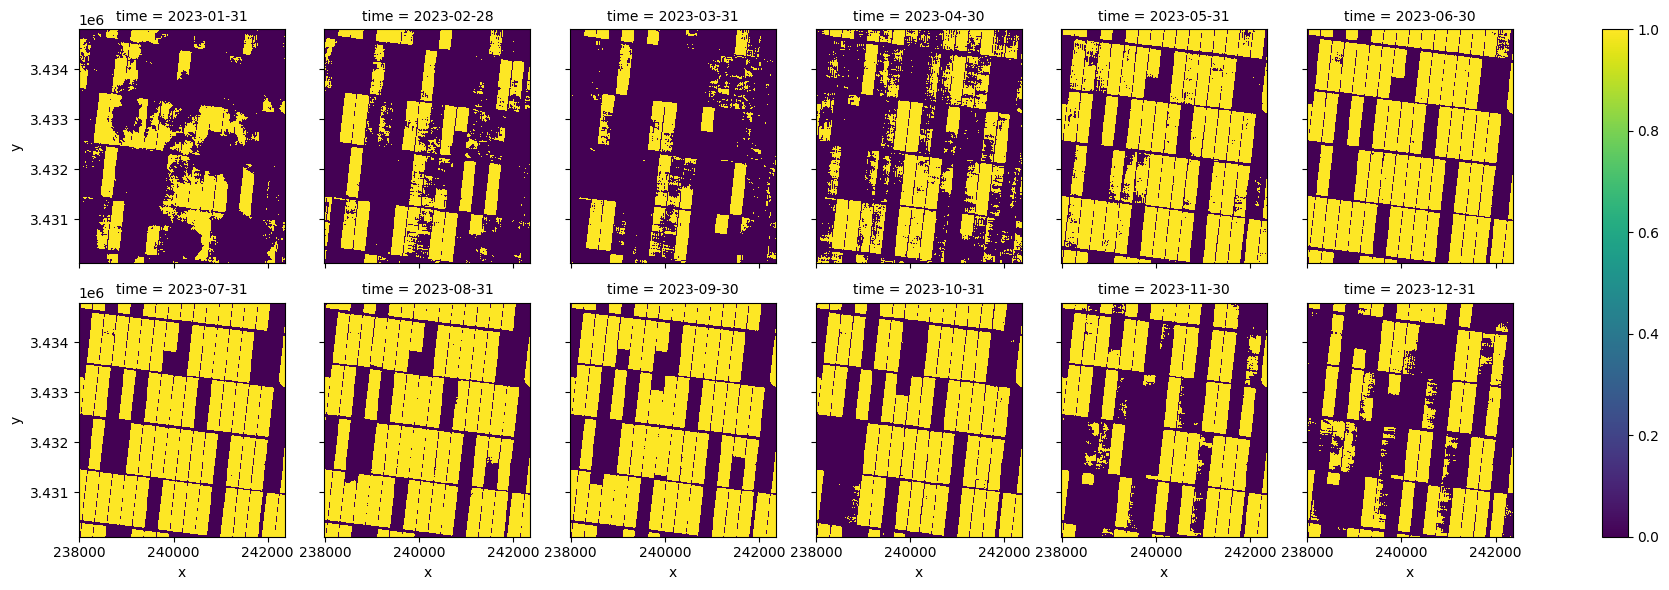

In [71]:
crop_layer.plot(col = 'time', col_wrap = 6)

In [73]:
crop_pixels = (crop_layer == 1).sum(dim = ['x','y'])
crop_area = crop_pixels * ((10 * 10)/1e6)

<Axes: xlabel='time'>

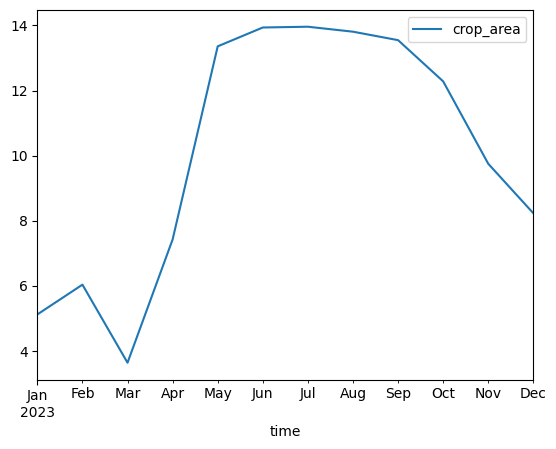

In [77]:
crop_area.to_dataframe('crop_area').plot()

In [79]:
crop_area.to_dataframe('crop_area').to_csv('crop_area.csv')